Extracting data from CSV...
Data transformed successfully!
Data loaded into 'loaded_sales_data.csv'


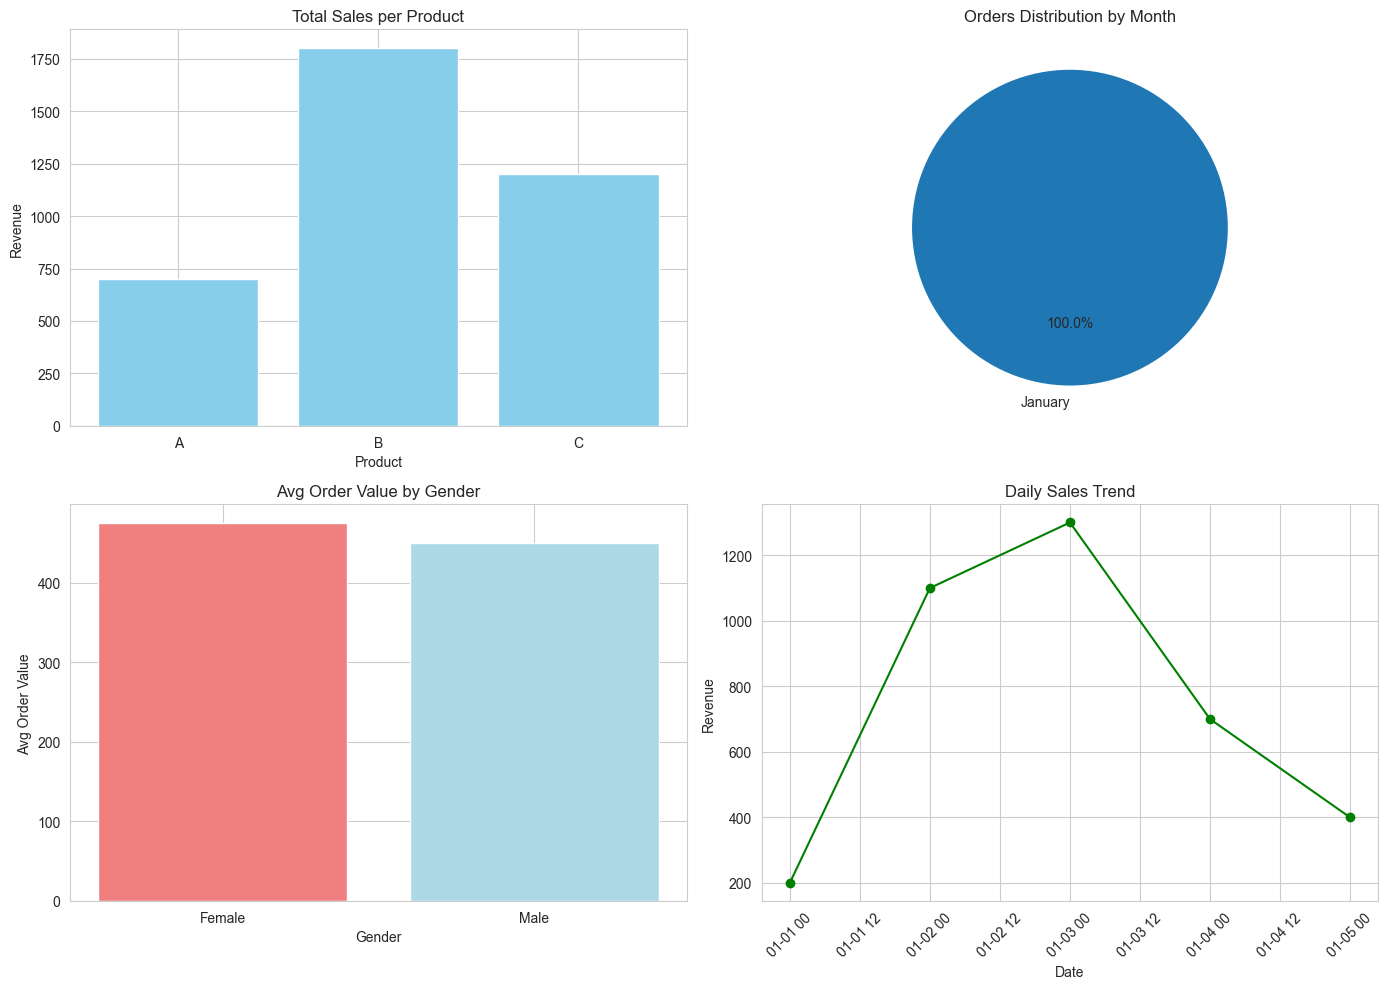

Visualization complete!


In [4]:
# ============================================================
# CL-4 Assignment 2 – ETL Process & Data Visualization
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional style
sns.set_style("whitegrid")
#%matplotlib inline   # remove if running in plain .py script

# ------------------------------------------------------------------
# 1. EXTRACT – read data from a CSV (or create a demo CSV)
# ------------------------------------------------------------------
# Create sample data (replace with your own CSV if you have one)
data = {
    'OrderID':    [101,102,103,104,105,106,107,108],
    'Product':    ['A','B','A','C','B','A','C','B'],
    'Quantity':   [2,5,1,3,2,4,1,2],
    'Price':      [100,200,100,300,200,100,300,200],
    'OrderDate':  ['2025-01-01','2025-01-02','2025-01-02','2025-01-03',
                   '2025-01-03','2025-01-04','2025-01-04','2025-01-05'],
    'CustomerGender': ['Male','Female','Female','Male','Male','Female','Male','Female']
}
df_raw = pd.DataFrame(data)
df_raw.to_csv('sales_data.csv', index=False)

# Extract
print("Extracting data from CSV...")
extracted_df = pd.read_csv('sales_data.csv')
extracted_df.head()

# ------------------------------------------------------------------
# 2. TRANSFORM – clean, encode, derive
# ------------------------------------------------------------------
df = extracted_df.copy()

# Convert date
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Encode Gender (Male → M, Female → F)
df['GenderCode'] = df['CustomerGender'].map({'Male':'M','Female':'F'})

# Derive TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']

# Extract month name
df['Month'] = df['OrderDate'].dt.month_name()

# Drop missing values (data cleansing)
df.dropna(inplace=True)

print("Data transformed successfully!")
df.head()

# ------------------------------------------------------------------
# 3. LOAD – save to a new CSV (our "data mart")
# ------------------------------------------------------------------
df.to_csv('loaded_sales_data.csv', index=False)
loaded_df = df.copy()
print("Data loaded into 'loaded_sales_data.csv'")

# ------------------------------------------------------------------
# 4. VISUALIZE – four charts
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 4.1 Total Sales per Product (bar)
sales_per_product = loaded_df.groupby('Product')['TotalPrice'].sum()
axes[0,0].bar(sales_per_product.index, sales_per_product.values, color='skyblue')
axes[0,0].set_title('Total Sales per Product')
axes[0,0].set_xlabel('Product')
axes[0,0].set_ylabel('Revenue')

# 4.2 Orders distribution by Month (pie)
month_counts = loaded_df['Month'].value_counts()
axes[0,1].pie(month_counts, labels=month_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Orders Distribution by Month')

# 4.3 Average Order Value by Gender (bar)
avg_gender = loaded_df.groupby('CustomerGender')['TotalPrice'].mean()
axes[1,0].bar(avg_gender.index, avg_gender.values, color=['lightcoral','lightblue'])
axes[1,0].set_title('Avg Order Value by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Avg Order Value')

# 4.4 Daily Sales Trend (line)
daily_sales = loaded_df.groupby('OrderDate')['TotalPrice'].sum().reset_index()
axes[1,1].plot(daily_sales['OrderDate'], daily_sales['TotalPrice'],
               marker='o', linestyle='-', color='green')
axes[1,1].set_title('Daily Sales Trend')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("Visualization complete!")

In [5]:
!pip install seaborn matplotlib pandas numpy


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
